### Environment configuration

In [1]:
import numpy as np

from nsqdriver import MCIDriver
from nsqdriver import QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM

SHARED_DEVICE_MEM.clear_ip()#reset ip

import tqdm
import nsqdriver.nswave as nw
import matplotlib.pyplot as plt
deviceIP ='192.168.110.224'
import time

In [3]:
!pip list
##python 3.11.9

Package                   Version
------------------------- -----------
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
astor                     0.8.1
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.7
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.62.1
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna            

### Initialization

In [5]:
deviceIP ='192.168.110.224'

driver = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(deviceIP)
da_rate_xy = 8e9
da_rate_rd = 8e9
da_rate_z = 4e9
da_rate_ll = 1e9
ad_rate = 4e9
sysparam = {
    "MixMode": 1,
    
    "RefClock": "out",
    "DArate_S12-O1": da_rate_z, 
    "DArate_S13-O1": da_rate_xy,
    "DArate_S15-O1": da_rate_ll,

    "DArate_S2-O1":da_rate_rd,

    "ADrate": ad_rate,

    "INMixMode": 1, 
    "CaptureMode": 1,  
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

qsync.open(system_parameter=qsync_param)
driver.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 12.4
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


### AWG playwaveform

In [6]:
shots = 0xffffffff
period = 100e-6
ch = "S13-O1"

In [7]:
freq = 100e6
t = 5e-6
amp = 1 
time_line = np.linspace(0, t, round(t*da_rate_xy), endpoint=False)
wave= amp*(np.cos(2*np.pi*freq*time_line)) 
driver.set("Waveform", wave,  ch) 


In [8]:
qsync.set('Shot', int(shots))
qsync.set("TrigWidth", 1e-6)
qsync.set('GenerateTrig', period)


In [9]:
qsync.set('ResetTrig') 

### AWG data acquisition （Play&capture 1us cos wave）

In [14]:
freq = 100e6
t = 1e-6
rd_width = 2e-6
capturemode = 1
time_line = np.linspace(0, t, round(t * da_rate_rd), endpoint=False)
wave = np.cos(2 * np.pi * freq * time_line)
ch_O = "S2-O1"
ch_I = "S2-I1"

In [15]:
driver.set("CaptureMode", capturemode)

driver.set("Shot", 64)
qsync.set("Shot", 64)

driver.set("TriggerDelay", 0, ch_I)
qsync.set("TrigPeriod", 100e-6)

driver.set("TimeWidth", rd_width, ch_I)

driver.set("Waveform", wave, ch_O)

In [16]:

driver.set("StartCapture")
qsync.set("GenerateTrig")

data = driver.get("TraceIQ", ch_I)

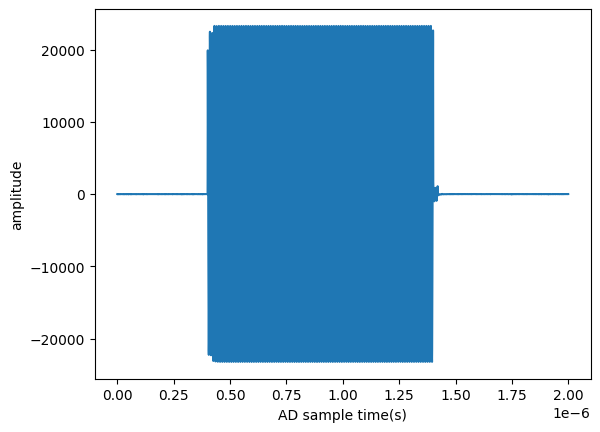

In [17]:

time_line_data = np.linspace(0, rd_width, round(rd_width * ad_rate), endpoint=False)
plt.plot(time_line_data, data.mean(axis=0))
plt.ylabel("amplitude")
plt.xlabel("AD sample time(s)")
plt.show()


### Phase  sweep (phase stability test)

In [18]:
deviceIP ='192.168.110.224'

driver = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(deviceIP)
da_rate_xy = 8e9
da_rate_rd = 8e9
da_rate_z = 4e9
ad_rate = 4e9
sysparam = {
    "MixMode": 2,
    
    "RefClock": "out",
    "DArate_S12-O1": da_rate_z, #slot 12  
    "DArate_S13-O1": da_rate_xy, #slot 11
    "DArate_S2-O1":da_rate_rd,# slo5 2
    "DArate_S15-O1": da_rate_z, #slot 12  

    "ADrate": ad_rate,

    "INMixMode": 1, 
    "CaptureMode": 1,  
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

qsync.open(system_parameter=qsync_param)
driver.open(system_parameter=sysparam)
qsync.sync_system()

*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 12.5
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


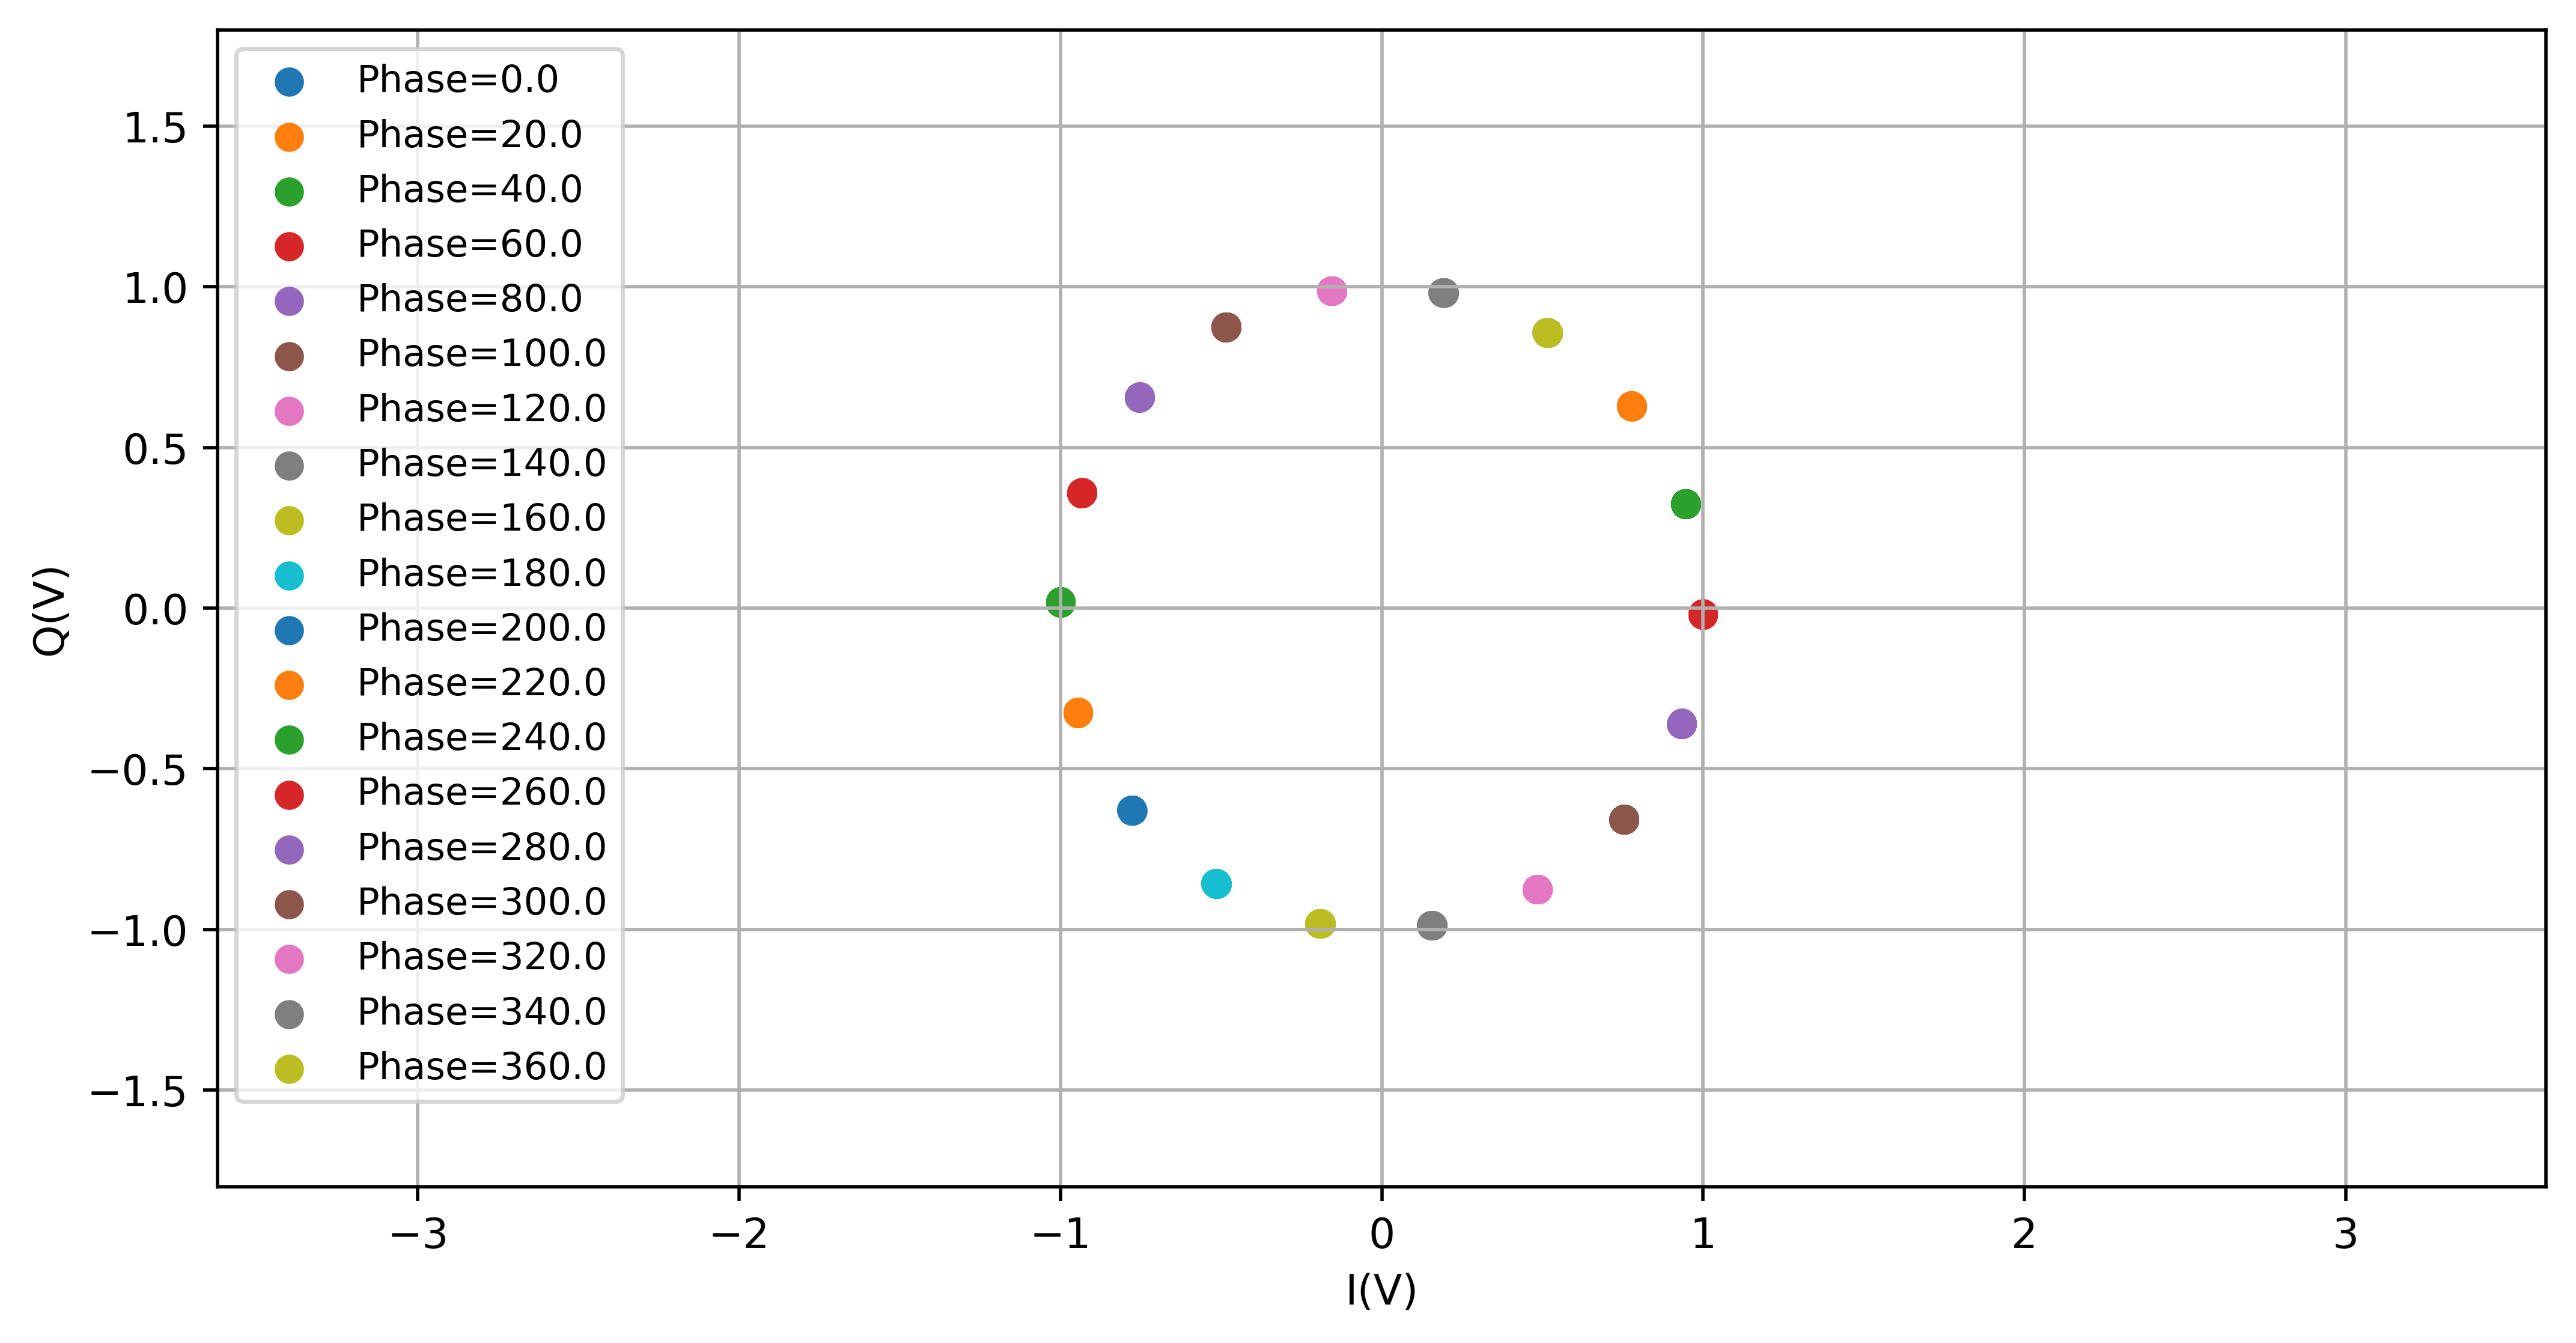

In [21]:
import math
freq = 4.3e9  # signal frequency
shots = 128
ch_O = "S2-O1"
ch_I = "S2-I1"
qsync.set("Shot", shots)
driver.set("Shot", shots)

qsync.set("TrigPeriod", 50e-6)

phi = np.linspace(0, 360, 19)

rd_ch = 1
rd_width = 2e-6  # in width，2us
rd_delay = 410e-9
t = 4.6e-6
I = []
Q = []
IQ = []
phi_spectrum = []

driver.set("CaptureMode", 0)
driver.set("TimeWidth", rd_width, ch_I)
driver.set("TriggerDelay", rd_delay, ch_I)

time_line = np.linspace(0, t, round(t * da_rate_rd), endpoint=False)
plt.figure(figsize=(10, 5), dpi=500)
for p in np.arange(len(phi)):
    wave = np.cos(2 * np.pi * freq * time_line + phi[p] * (np.pi / 180))
    driver.set("Waveform", wave, ch_O)  # play waveform
    driver.set("FreqList", [float(freq)], ch_I)
    driver.set("StartCapture")  # start
    qsync.set("GenerateTrig")  # gen trig
    phi_spectrum = driver.get("IQ", ch_I)
    I = phi_spectrum.real
    Q = phi_spectrum.imag
    phi_spectrum_norm = np.sqrt(I**2 + Q**2)
    phi_spectrum = phi_spectrum / phi_spectrum_norm
    phi_spectrum = phi_spectrum.T
    I = phi_spectrum.real
    Q = phi_spectrum.imag
    IQ.append([I,Q])
    plt.scatter(I, Q, label=f"Phase={phi[p]}")
    plt.axis("equal")
    plt.ylabel("Q(V)")
    plt.xlabel("I(V)")
    plt.xlim(-5, 5)
    plt.ylim(-1.8, 1.8)
    plt.grid(True)
    plt.legend()


plt.legend(prop={"size": 9}, loc="upper left")
plt.show()


### S21

In [22]:
driver = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(deviceIP)
da_rate_xy = 8e9
da_rate_rd = 8e9
da_rate_z = 4e9
da_ra_ll = 1e9
ad_rate = 4e9
sysparam = {
    "MixMode": 1,
    
    "RefClock": "out",
    "DArate_S12-O1": da_rate_z, #slot 12  
    "DArate_S13-O1": da_rate_xy, #slot 11
    "DArate_S2-O1":da_rate_rd,# slot2
    "DArate_S15-O1":da_ra_ll,# slot 15
    "ADrate": ad_rate,

    "INMixMode": 1, 
    "CaptureMode": 1,  
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

qsync.open(system_parameter=qsync_param)
driver.open(system_parameter=sysparam)
qsync.sync_system()


*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 12.5
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  8.78it/s]


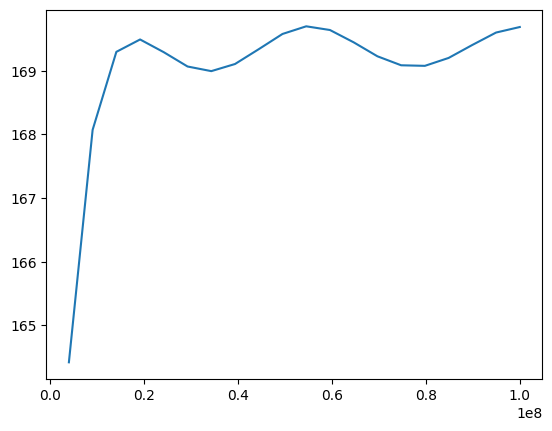

In [26]:
in_ch = 'S2-I1'
out_ch = 'S2-O1'
freq_range = np.linspace(4e6, 100e6, 20)# sweep freq
wave_width = 2e-6
wave_amp = 1
shots = 64
time_line = np.linspace(0, wave_width, round(wave_width*da_rate_rd), endpoint=False)
driver.set('Shot', shots) # Set the number of shots the device should receive
qsync.set('Shot', shots) # Set the number of triggers generated by qsync
qsync.set('TrigPeriod', 500e-6) # Set qsync trigger period
driver.set('TimeWidth', 2e-6, in_ch) # Set the sampling time width for the IN channel
# Start sweeping over frequency points
s21_res = []
s21_rms_norm_res = []
for freq in tqdm.tqdm(freq_range):
    wave = wave_amp * np.cos(2*np.pi*freq*time_line)
    driver.set('Waveform', wave, out_ch) # Download waveform to the corresponding OUT channel
    driver.set('FreqList', [float(freq)], in_ch) # Configure demodulation frequency for the corresponding IN channel
    driver.set('StartCapture') # Notify the IN channel to start acquisition
    qsync.set('GenerateTrig')
    iq_data = np.asarray(driver.get('IQData', in_ch))
    s21_res.append(iq_data) 
s21_res = np.array(s21_res).mean(axis=1)
s21_power = 20*np.log10(np.abs(s21_res))
plt.plot(freq_range, s21_power)
plt.show()

### SPECTRUM

In [27]:
deviceIP ='192.168.110.224'

driver = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(deviceIP)
da_rate_xy = 8e9
da_rate_rd = 8e9
da_rate_z = 4e9
da_rate_ll = 1e9
ad_rate = 4e9
sysparam = {
    "MixMode": 1,
    
    "RefClock": "out",
    "DArate_S12-O1": da_rate_z, #slot 12  
    "DArate_S13-O1": da_rate_xy, #slot 13
    "DArate_S2-O1":da_rate_rd,# slo5 2
    "DArate_S15-O1":da_rate_ll,# slo5 2

    "ADrate": ad_rate,

    "INMixMode": 1, 
    "CaptureMode": 1,  
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

qsync.open(system_parameter=qsync_param)
driver.open(system_parameter=sysparam)
qsync.sync_system()


*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 12.5
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  9.79it/s]


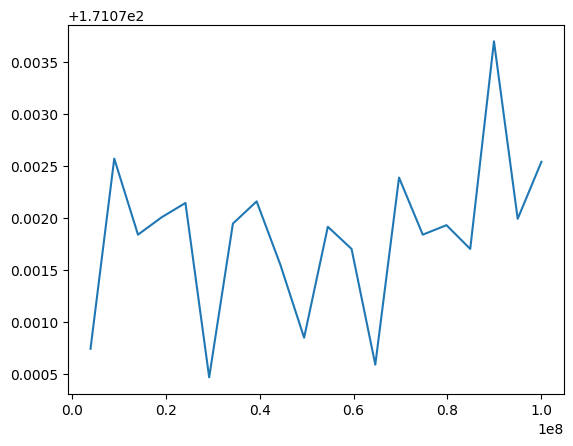

In [28]:
## Set channel parameters
xy_ch = "S13-O1"  ## Use OUT1 channel for xy drive
probe_out_ch = "S2-O1"
probe_in_ch = "S2-I1"
probe_freq = 40e6
probe_width = 2e-6
drive_width = 2e-6
xy_amp = 1
probe_amp = 1
shots = 64

## Configure probe-related waveform
time_line = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)
driver.set("Shot", shots)  ## Set hardware demodulation run count for IN channel
zero_num = round((drive_width) * da_rate_rd)  ## Number of zeros to pad for the remaining delay
wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)
## Delay probe waveform by drive_width
wave = np.hstack([np.zeros(zero_num), wave])
driver.set("Waveform", wave, probe_out_ch)  ## Download waveform to the corresponding OUT channel
driver.set("TimeWidth", probe_width, probe_in_ch)  ## Set sampling time width for IN channel
driver.set("FreqList", [float(probe_freq)], probe_in_ch) 
driver.set("INDelay", drive_width+400e-9, probe_in_ch)


## Set qsync trigger period
qsync.set("Shot", shots)  ## Set number of triggers generated by qsync
qsync.set("TrigPeriod", 500e-6)
time_line = np.linspace(0, drive_width, round(drive_width * da_rate_xy), endpoint=False)
freq_range = np.linspace(4e6, 100e6, 20)
## Start frequency sweep
spectrum_res = []
for freq in tqdm.tqdm(freq_range):
    wave = xy_amp * np.cos(2 * np.pi * freq * time_line)
    driver.set("Waveform", wave, xy_ch)  ## Download waveform to the corresponding OUT channel
    driver.set("StartCapture")
    qsync.set("GenerateTrig")  ## Generate trigger signal
    iq_data = np.asarray(driver.get('IQData', probe_in_ch))
    spectrum_res.append(iq_data) 

 
spectrum_res = np.array(spectrum_res).mean(axis=1)
spectrum_res_power = 20*np.log10(np.abs(spectrum_res))
plt.plot(freq_range,spectrum_res_power)
plt.show()

### SPECTRUM VS FLUX


In [29]:
deviceIP ='192.168.110.224'

driver = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(deviceIP)
da_rate_xy = 8e9
da_rate_rd = 8e9
da_rate_z = 4e9
da_rate_ll = 1e9
ad_rate = 4e9
sysparam = {
    "MixMode": 1,
    
    "RefClock": "out",
    "DArate_S12-O1": da_rate_z, #slot 12  
    "DArate_S13-O1": da_rate_xy, #slot 11
    "DArate_S2-O1":da_rate_rd,# slo5 2
    "DArate_S15-O1":da_rate_ll,# slo5 2

    "ADrate": ad_rate,

    "INMixMode": 1, 
    "CaptureMode": 1,  
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

qsync.open(system_parameter=qsync_param)
driver.open(system_parameter=sysparam)
qsync.sync_system()


*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 12.5
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


In [42]:
## Initialize waveform and experiment parameters
xy_ch = 'S13-O1'               ## Use OUT3 channel for xy drive
drive_width = 1e-6
xy_amp = 1

# z_ch = 'S12-O1'
z_ch = 'S15-O1'

probe_bias = 1       ## Bias value used during readout

probe_ch_in = 'S2-I1'            ## Probe uses IN1 and OUT1 channels
probe_ch_out = 'S2-O1'
probe_freq = 40e6
probe_width = 1e-6
probe_amp = 1
shots = 64
time_line = np.linspace(0, probe_width, round(probe_width*da_rate_rd), endpoint=False)

# Set capture count and probe pulse
driver.set('Shot', shots)                                  ## Set hardware demodulation run count for IN channel
zero_num = round((drive_width) * da_rate_rd)  ## Calculate number of zeros to pad
wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)
wave = np.hstack([np.zeros(zero_num), wave])

driver.set("Waveform", wave, probe_ch_out)  ## Download waveform to the corresponding OUT channel

qsync.set('Shot', shots)                                ## Set number of triggers generated by qsync
qsync.set('TrigPeriod', 500e-6)                         ## Set qsync trigger period
time_line = np.linspace(0, drive_width, round(drive_width*da_rate_rd), endpoint=False)
freq_range = np.linspace(4e6, 100e6,50)
bias_range = np.linspace(-1, 1, 20)
driver.set("INDelay", drive_width+400e-9, probe_in_ch)
driver.set("TimeWidth", probe_width, probe_in_ch)  ## Set sampling time width for IN channel
driver.set("FreqList", [float(probe_freq)], probe_in_ch)  
## Start bias sweep
spectrum_vs_flux = []
for bias in tqdm.tqdm(bias_range):
    
    # wave =bias*np.ones(round(da_rate_z *(drive_width+0.6e-6)))# Generate square waveform
    wave =bias*np.ones(round(da_rate_ll *(drive_width)))# Generate square waveform

    wave[-1]=0
    driver.set('Waveform', wave, z_ch)  ## Download waveform to the corresponding OUT channel

    _probe = probe_bias*np.ones((int(probe_width), ))
    ## Start frequency sweep
    spectrum_res = []
    for freq in freq_range:
        wave = xy_amp * np.cos(2*np.pi*freq*time_line)
        driver.set('Waveform', wave, xy_ch)                    ## Download waveform to the corresponding OUT channel
        driver.set("StartCapture")
        qsync.set("GenerateTrig")  ## Generate trigger signal
        iq_data = np.asarray(driver.get('IQData', probe_in_ch))
        spectrum_res.append(iq_data) 


 15%|████████████▍                                                                      | 3/20 [00:15<01:30,  5.32s/it]


KeyboardInterrupt: 

## TIME RABI

In [32]:
deviceIP ='192.168.110.224'

driver = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(deviceIP)
da_rate_xy = 8e9
da_rate_rd = 8e9
da_rate_z = 4e9
da_rate_ll = 1e9
ad_rate = 4e9
sysparam = {
    "MixMode": 1,
    
    "RefClock": "out",
    "DArate_S12-O1": da_rate_z, #slot 12  
    "DArate_S13-O1": da_rate_xy, #slot 11
    "DArate_S2-O1":da_rate_rd,# slo5 2
    "DArate_S15-O1":da_rate_ll,# slo5 2

    "ADrate": ad_rate,

    "INMixMode": 1, 
    "CaptureMode": 1,  
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

qsync.open(system_parameter=qsync_param)
driver.open(system_parameter=sysparam)
qsync.sync_system()


*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 12.5
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:15<00:00,  6.45it/s]


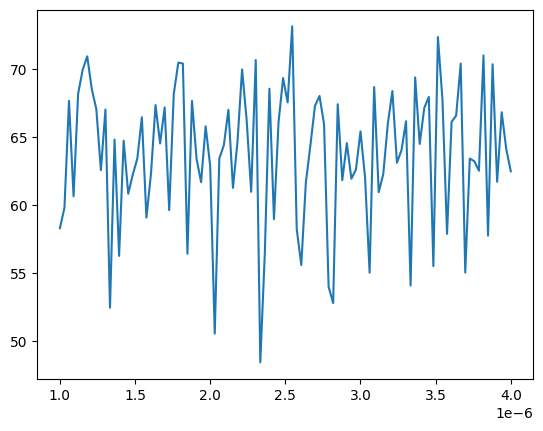

In [34]:
xy_ch = "S13-O1"  ## Use OUT3 channel for xy drive
probe_out_ch = "S2-O1"
probe_in_ch = "S2-I1"
# z_ch = "S12-O1"
z_ch = "S15-O1"  # LiangLong Channel


probe_freq = 40e6
xy_freq = 40e6
probe_width = 1e-6
probe_amp = 1
shots = 64
bias = 1
probe_bias = 1
driver.set("Shot", shots)  ## Set hardware demodulation run count for IN channel
driver.set("TimeWidth", probe_width, probe_in_ch)  ## Set IN channel sampling time width
qsync.set("Shot", shots)  ## Set number of triggers generated by qsync
qsync.set("TrigPeriod", 500e-6)  ## Set qsync trigger period
driver.set("FreqList", [float(probe_freq)], probe_in_ch)  
time_range = np.linspace(1e-6,4e-6,100)

## Start time sweep
spectrum_res = []
for drive_width in tqdm.tqdm(time_range):
    time_line = np.linspace(0, drive_width, round(drive_width * da_rate_xy), endpoint=False)
    wave = xy_amp * np.cos(2 * np.pi * xy_freq * time_line)
    driver.set("Waveform", wave, xy_ch)  ## Download waveform to the corresponding OUT channel
    ## Recalculate probe waveform delay
    time_line = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)

    wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)

    driver.set("Delay", drive_width, probe_out_ch)  ## Set probe outdelay (16 ns granularity)
    driver.set("Waveform", wave, probe_out_ch)  ## Download waveform to the corresponding OUT channel
    driver.set("INDelay", drive_width+400e-9, probe_in_ch)

    ## Recalculate Z waveform length
    wave =bias*np.ones(round(da_rate_ll *(drive_width)))# Generate square waveform
    # wave =bias*np.ones(round(da_rate_z *(drive_width)))# Generate square waveform
    wave[-1]=0
    driver.set('Waveform', wave, z_ch)  ## Download waveform to the corresponding OUT channel
    driver.set("StartCapture")
    qsync.set("GenerateTrig")  ## Generate trigger signal
    iq_data = np.asarray(driver.get('IQData', probe_in_ch))
    spectrum_res.append(iq_data) 
specrum_res = np.array(spectrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.plot(time_range, specrum_power)
plt.show()  


## POWER RABI

In [35]:
deviceIP ='192.168.110.224'

driver = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(deviceIP)
da_rate_xy = 8e9
da_rate_rd = 8e9
da_rate_z = 4e9
da_rate_ll = 1e9
ad_rate = 4e9
sysparam = {
    "MixMode": 1,
    
    "RefClock": "out",
    "DArate_S12-O1": da_rate_z, #slot 12  
    "DArate_S13-O1": da_rate_xy, #slot 11
    "DArate_S2-O1":da_rate_rd,# slo5 2
    "DArate_S15-O1":da_rate_ll,# slo5 2

    "ADrate": ad_rate,

    "INMixMode": 1, 
    "CaptureMode": 1,  
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

qsync.open(system_parameter=qsync_param)
driver.open(system_parameter=sysparam)
qsync.sync_system()


*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 12.5
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.32it/s]


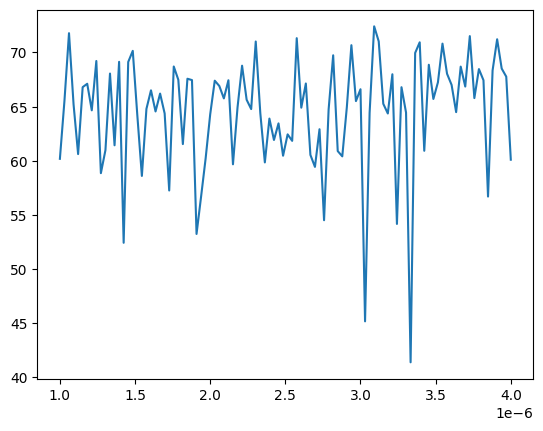

In [36]:
xy_ch = "S13-O1"  ## Use OUT3 channel for xy drive
probe_out_ch = "S2-O1"
probe_in_ch = "S2-I1"
# z_ch = "S12-O1"
z_ch = "S15-O1"  # LiangLong Channel

drive_width = 1e-6
probe_freq = 40e6
xy_freq = 40e6
probe_width = 1e-6
probe_amp = 1
shots = 64
bias = 1
probe_bias = 1
driver.set("Shot", shots)  ## Set hardware demodulation run count for IN channel
driver.set("TimeWidth", probe_width, probe_in_ch)  ## Set IN channel sampling time width
qsync.set("Shot", shots)  ## Set number of triggers generated by qsync
qsync.set("TrigPeriod", 500e-6)  ## Set qsync trigger period
driver.set("FreqList", [float(probe_freq)], probe_in_ch)  
driver.set("INDelay", drive_width+400e-9, probe_in_ch)
amp_range = np.linspace(0,1,100)

## Start power sweep
spectrum_res = []
for xy_amp in tqdm.tqdm(amp_range):
    time_line = np.linspace(0, drive_width, round(drive_width * da_rate_xy), endpoint=False)
    wave = xy_amp * np.cos(2 * np.pi * xy_freq * time_line)
    driver.set("Waveform", wave, xy_ch)  ## Download waveform to the corresponding OUT channel
    ## Recalculate probe waveform delay
    time_line = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)

    wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)

    driver.set("Delay", drive_width, probe_out_ch)  ## Set probe outdelay (16 ns granularity)
    driver.set("Waveform", wave, probe_out_ch)  ## Download waveform to the corresponding OUT channel


    ## Recalculate Z waveform length
    wave =bias*np.ones(round(da_rate_ll *(drive_width)))# Generate square waveform
    # wave =bias*np.ones(round(da_rate_z *(drive_width)))# Generate square waveform
    wave[-1]=0
    driver.set('Waveform', wave, z_ch)  ## Download waveform to the corresponding OUT channel
    driver.set('StartCapture')
    qsync.set("GenerateTrig")  ## Generate trigger signal
    iq_data = np.asarray(driver.get('IQData', probe_in_ch))
    spectrum_res.append(iq_data) 
specrum_res = np.array(spectrum_res).mean(axis=1)
specrum_power = 20 * np.log10(np.abs(specrum_res))
plt.plot(time_range, specrum_power)
plt.show()    

## T1

In [37]:
deviceIP ='192.168.110.224'

driver = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(deviceIP)
da_rate_xy = 8e9
da_rate_rd = 8e9
da_rate_z = 4e9
da_rate_ll = 1e9
ad_rate = 4e9
sysparam = {
    "MixMode": 1,
    
    "RefClock": "out",
    "DArate_S12-O1": da_rate_z,   
    "DArate_S13-O1": da_rate_xy, 
    "DArate_S2-O1":da_rate_rd,
    "DArate_S15-O1":da_rate_ll,

    "ADrate": ad_rate,

    "INMixMode": 1, 
    "CaptureMode": 1,  
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

qsync.open(system_parameter=qsync_param)
driver.open(system_parameter=sysparam)
qsync.sync_system()


*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 12.6
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


100%|████████████████████████████████████████████████████████████████████████████████| 101/101 [00:14<00:00,  7.11it/s]


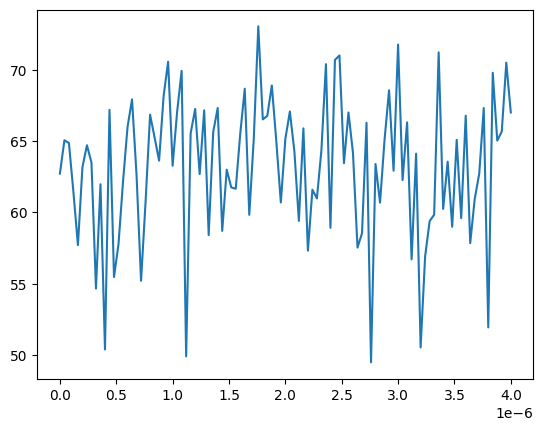

In [39]:
xy_ch = "S13-O1"  ## Use OUT3 channel for xy drive
probe_out_ch = "S2-O1"
probe_in_ch = "S2-I1"
# z_ch = "S12-O1"
z_ch = "S15-O1"  # LiangLong Channel


probe_freq = 40e6
xy_freq = 40e6
probe_width = 1e-6
drive_width = 1e-6
probe_amp = 1
xy_amp = 1
shots = 64
bias = 1
probe_bias = 1
driver.set("Shot", shots)  ## Set hardware demodulation run count for IN channel
driver.set("TimeWidth", probe_width, probe_in_ch)  ## Set IN channel sampling time width
qsync.set("Shot", shots)  ## Set number of triggers generated by qsync
qsync.set("TrigPeriod", 500e-6)  ## Set qsync trigger period

probe_time_range = np.linspace(0,4e-6,101)
## Start probe time sweep
spectrum_res=[]
for probe_time in tqdm.tqdm(probe_time_range):
    time_line = np.linspace(0, drive_width, round(drive_width * da_rate_xy), endpoint=False)
    wave = xy_amp * np.cos(2 * np.pi * xy_freq * time_line)
    driver.set("Waveform", wave, xy_ch)  ## Download waveform to the corresponding OUT channel
    ## Recalculate probe waveform delay
    time_line = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)

    wave = probe_amp * np.cos(2 * np.pi * probe_freq * time_line)
    driver.set("INDelay", drive_width + probe_time + 400e-9, probe_in_ch)
    driver.set("Delay", drive_width+probe_time, probe_out_ch)  ## Set probe outdelay (16 ns granularity)
    driver.set("Waveform", wave, probe_out_ch)  ## Download waveform to the corresponding OUT channel


    ## Recalculate Z waveform length
    wave =bias*np.ones(round(da_rate_ll *(drive_width)))# Generate square waveform
    # wave =bias*np.ones(round(da_rate_z *(drive_width+400e-9)))# Generate square waveform
    wave[-1]=0
    driver.set('Waveform', wave, z_ch)  ## Download waveform to the corresponding OUT channel
    driver.set('StartCapture')
    qsync.set("GenerateTrig")  ## Generate trigger signal
    iq_data = np.asarray(driver.get('IQData', probe_in_ch))
    spectrum_res.append(iq_data) 

spectrum_res = np.array(spectrum_res).mean(axis=1)
spectrum_power = 20 * np.log10(np.abs(spectrum_res))
plt.plot(probe_time_range, spectrum_power)
plt.show()

## T2 

In [40]:
deviceIP ='192.168.110.224'

driver = MCIDriver(deviceIP, 40)
qsync = QSYNCDriver(deviceIP)
da_rate_xy = 8e9
da_rate_rd = 8e9
da_rate_z = 4e9
da_rate_ll = 1e9
ad_rate = 4e9
sysparam = {
    "MixMode": 1,
    
    "RefClock": "out",
    "DArate_S12-O1": da_rate_z, 
    "DArate_S13-O1": da_rate_xy, 
    "DArate_S2-O1":da_rate_rd,
    "DArate_S15-O1":da_rate_ll,

    "ADrate": ad_rate,

    "INMixMode": 1, 
    "CaptureMode": 1,  
}
qsync_param = {"TrigFrom": 0, "RefClock": "in"}

qsync.open(system_parameter=qsync_param)
driver.open(system_parameter=sysparam)
qsync.sync_system()


*********QSYNC192.168.110.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 192.168.110.224 opened successfully
*********设备192.168.110.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 12.5
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
192.168.110.224开启成功
System synchronization succeeded


100%|████████████████████████████████████████████████████████████████████████████████| 251/251 [00:37<00:00,  6.75it/s]


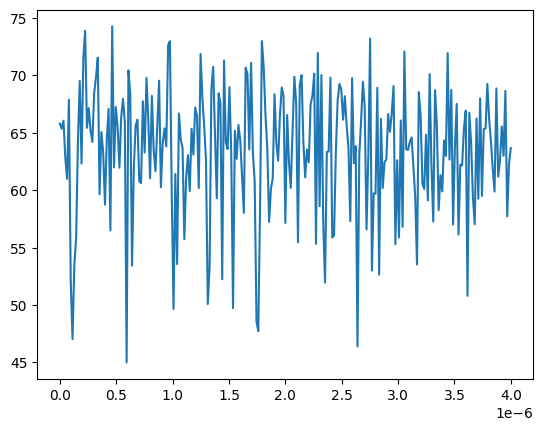

In [41]:
xy_ch = "S13-O1"  ## Use OUT1 channel for xy drive
probe_out_ch = "S2-O1"
probe_in_ch = "S2-I1"
# z_ch = "S12-O1"
z_ch = "S15-O1"  # LiangLong Channel


probe_freq = 40e6
xy_freq = 40e6
probe_width = 1e-6
probe_amp = 1
xy_amp = 1
shots = 64
bias = 1
probe_bias = 1
driver.set("Shot", shots)  ## Set hardware demodulation run count for IN channel
driver.set("TimeWidth", probe_width, probe_in_ch)  ## Set IN channel sampling time width
qsync.set("Shot", shots)  ## Set number of triggers generated by qsync
qsync.set("TrigPeriod", 500e-6)  ## Set qsync trigger period

xy_pulse_width = 0.5e-6
probe_time_step = 16e-9
probe_time_range = np.arange(0, 4e-6 + 0.5 * probe_time_step, probe_time_step)
spectrum_res=[]
## Start T2 sweep
for probe_time in tqdm.tqdm(probe_time_range):
    # Build XY waveform: pulse1 + interval(probe_time) + pulse2
    pulse_samples = round(xy_pulse_width * da_rate_xy)
    gap_samples = round(probe_time * da_rate_xy)
    total_samples = pulse_samples + gap_samples + pulse_samples

    xy_wave = np.zeros(total_samples)
    t_pulse = np.arange(pulse_samples) / da_rate_xy
    xy_pulse = xy_amp * np.cos(2 * np.pi * xy_freq * t_pulse)
    xy_wave[:pulse_samples] = xy_pulse
    xy_wave[pulse_samples + gap_samples:pulse_samples + gap_samples + pulse_samples] = xy_pulse
    driver.set("Waveform", xy_wave, xy_ch)  ## Download waveform to the corresponding OUT channel

    # Place probe waveform after the second XY pulse
    probe_time_line = np.linspace(0, probe_width, round(probe_width * da_rate_rd), endpoint=False)
    probe_wave = probe_amp * np.cos(2 * np.pi * probe_freq * probe_time_line)
    total_xy_width = total_samples / da_rate_xy
    driver.set("Delay", total_xy_width, probe_out_ch)
    driver.set("INDelay", total_xy_width+400e-9, probe_in_ch)
    driver.set("Waveform", probe_wave, probe_out_ch)  ## Download waveform to the corresponding OUT channel

    ## Recalculate Z waveform length
    z_wave = bias * np.ones(round(da_rate_ll * total_xy_width))  # Generate square waveform
    z_wave[-1] = 0
    driver.set('Waveform', z_wave, z_ch)  ## Download waveform to the corresponding OUT channel
    driver.set('StartCapture')
    qsync.set("GenerateTrig")  ## Generate trigger signal
    iq_data = np.asarray(driver.get('IQData', probe_in_ch))
    spectrum_res.append(iq_data) 
spectrum_res = np.array(spectrum_res).mean(axis=1)
spectrum_power = 20 * np.log10(np.abs(spectrum_res))
plt.plot(probe_time_range, spectrum_power)
plt.show()
